# Actividad 3 — EDA · Agraria.pe

**Objetivo:** Analizar la cobertura y contenido de las noticias como señal para el modelo, identificar patrones temporales y evaluar la calidad del texto para la Fase 2 (BETO).

**Entrada:** `pipeline/output/02_lectura/agraria_raw.csv`
**Salidas:** Graficos en `pipeline/output/03_eda/act03_agraria_*.png`


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings, unicodedata
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']
print('Config cargado OK | Raiz:', os.getcwd())


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## Carga de datos Agraria.pe


In [2]:
df_agr = pd.read_csv(OUTPUT['lectura'] + 'agraria_raw.csv',
                     on_bad_lines='skip', low_memory=False)
df_agr['fecha_dt'] = pd.to_datetime(df_agr['fecha'], errors='coerce')
df_agr['anio'] = df_agr['fecha_dt'].dt.year
df_agr['mes']  = df_agr['fecha_dt'].dt.month
df_agr['fecha_mes'] = df_agr['fecha_dt'].dt.to_period('M').dt.to_timestamp()
print(f'Shape: {df_agr.shape}')
print(f'Rango: {df_agr["fecha_dt"].min().date()} -> {df_agr["fecha_dt"].max().date()}')
print(f'Noticias totales: {len(df_agr):,}')


Shape: (528, 10)
Rango: 2021-01-04 -> 2025-12-22
Noticias totales: 528


## 3.1 Grafico 1 — Noticias por categoria/fuente


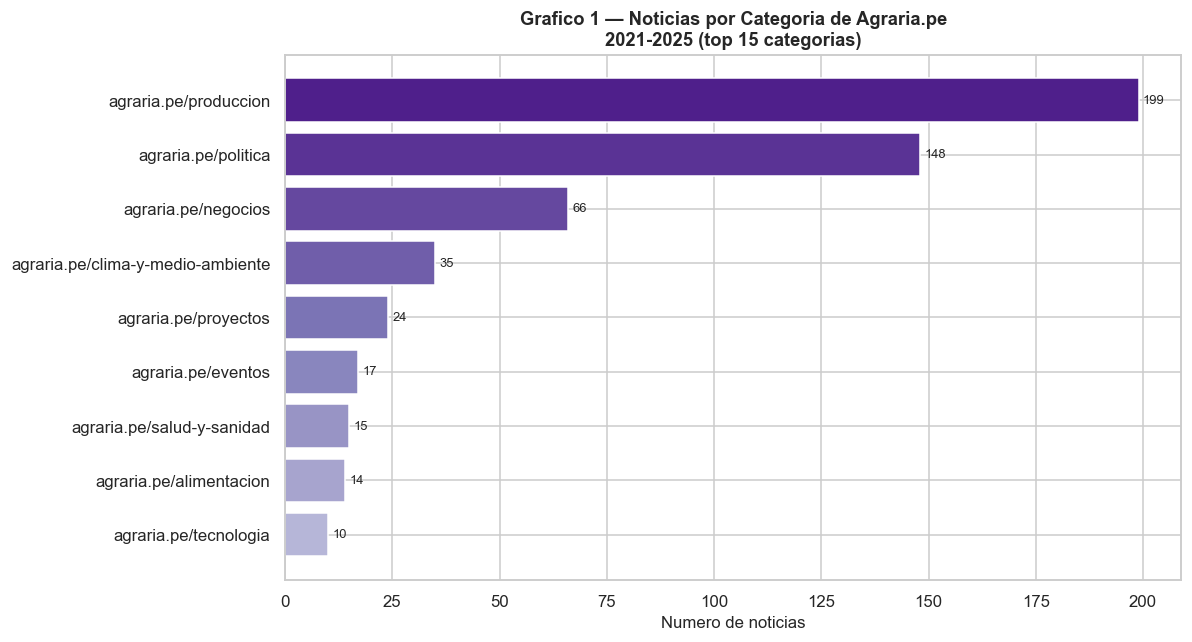

Guardado: pipeline/output/03_eda/act03_agraria_g1_categorias.png


In [3]:
if 'fuente' in df_agr.columns:
    cat_counts = df_agr['fuente'].value_counts().sort_values(ascending=True).tail(15)
    fig, ax = plt.subplots(figsize=(11, 6))
    colors_cat = plt.cm.Purples(np.linspace(0.4, 0.9, len(cat_counts)))
    ax.barh(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='white')
    for i, val in enumerate(cat_counts.values):
        ax.text(val + 1, i, f'{int(val):,}', va='center', fontsize=8.5)
    ax.set_xlabel('Numero de noticias', fontsize=11)
    ax.set_title('Grafico 1 — Noticias por Categoria de Agraria.pe\n'
                 '2021-2025 (top 15 categorias)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    g = OUTPUT['eda'] + 'act03_agraria_g1_categorias.png'
    plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g)
else:
    print('Columna fuente no encontrada.')


### Interpretacion

**Que muestra:** La distribucion de noticias por categoria del sitio Agraria.pe. Las categorias dominantes indican que tipo de contenido tiene mayor cobertura.

**Implicacion para el pipeline:** Si algunas categorias tienen muy pocas noticias, pueden filtrarse en la Actividad 5 para reducir ruido. Las categorias de produccion, precios y clima son las mas relevantes para el modelo.

**Implicacion para el modelo:** Para la Fase 1 solo se usa el conteo mensual de noticias. Para la Fase 2 (BETO), la categoria puede usarse como contexto adicional para el analisis de sentimiento.


## 3.2 Grafico 2 — Serie temporal de noticias mensuales


Correlacion noticias vs produccion: -0.096


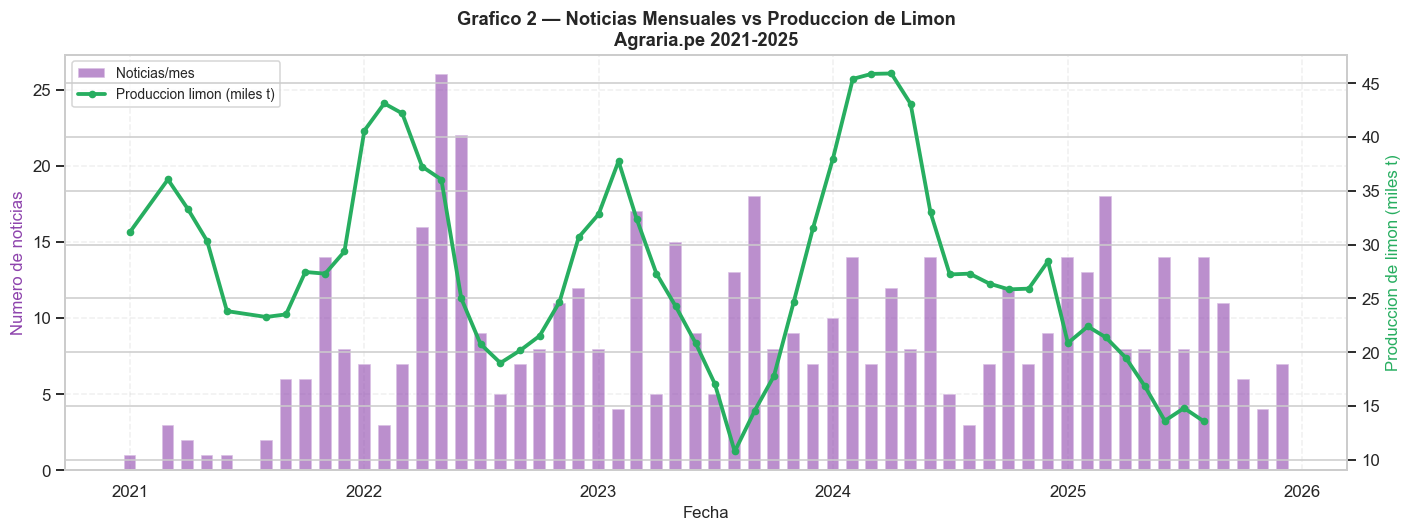

Guardado: pipeline/output/03_eda/act03_agraria_g2_serie.png


In [4]:
serie_noticias = df_agr.groupby('fecha_mes').size().reset_index(name='n_noticias')
serie_noticias = serie_noticias.sort_values('fecha_mes')

# Cargar produccion de limon para comparacion
xl = pd.ExcelFile(SOURCES['midagri'])
dfs_m = [pd.read_excel(SOURCES['midagri'], sheet_name=s) for s in xl.sheet_names]
df_m = pd.concat(dfs_m, ignore_index=True)
df_limon = df_m[df_m['dsc_Cultivo'].str.upper().str.contains('LIMON', na=False)].copy()
df_limon['fecha_mes'] = pd.to_datetime(
    df_limon['anho'].astype(str) + '-' + df_limon['mes'].astype(str).str.zfill(2) + '-01'
)
prod_mensual = df_limon.groupby('fecha_mes')['PRODUCCION(t)'].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(serie_noticias['fecha_mes'], serie_noticias['n_noticias'],
        color='#8e44ad', alpha=0.6, width=20, label='Noticias/mes')

df_comp_agr = pd.merge(serie_noticias, prod_mensual, on='fecha_mes', how='inner')
if len(df_comp_agr) > 0:
    ax2.plot(df_comp_agr['fecha_mes'], df_comp_agr['PRODUCCION(t)']/1e3,
             color='#27ae60', linewidth=2.5, marker='o', markersize=4,
             label='Produccion limon (miles t)')
    corr_agr = df_comp_agr['n_noticias'].corr(df_comp_agr['PRODUCCION(t)'])
    print(f'Correlacion noticias vs produccion: {corr_agr:.3f}')

ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Numero de noticias', fontsize=11, color='#8e44ad')
ax2.set_ylabel('Produccion de limon (miles t)', fontsize=11, color='#27ae60')
ax1.set_title('Grafico 2 — Noticias Mensuales vs Produccion de Limon\n'
             'Agraria.pe 2021-2025', fontsize=12, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_agraria_g2_serie.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La evolucion mensual del numero de noticias junto con la produccion de limon. Si los meses con mas noticias coinciden con picos o caidas de produccion, la variable `n_noticias` tiene poder predictivo.

**Implicacion para el pipeline:** Meses con 0 noticias son validos si reflejan ausencia real de cobertura. Se documentaran en la Actividad 4 para verificar que no sean errores de scraping.

**Implicacion para el modelo:** La correlacion entre noticias y produccion justifica incluir `n_noticias` como variable exogena en el LSTM-Attention. Para la Fase 2, el sentimiento de las noticias (BETO) aportara informacion cualitativa adicional.


## 3.3 Grafico 3 — Longitud de titulares y cuerpos


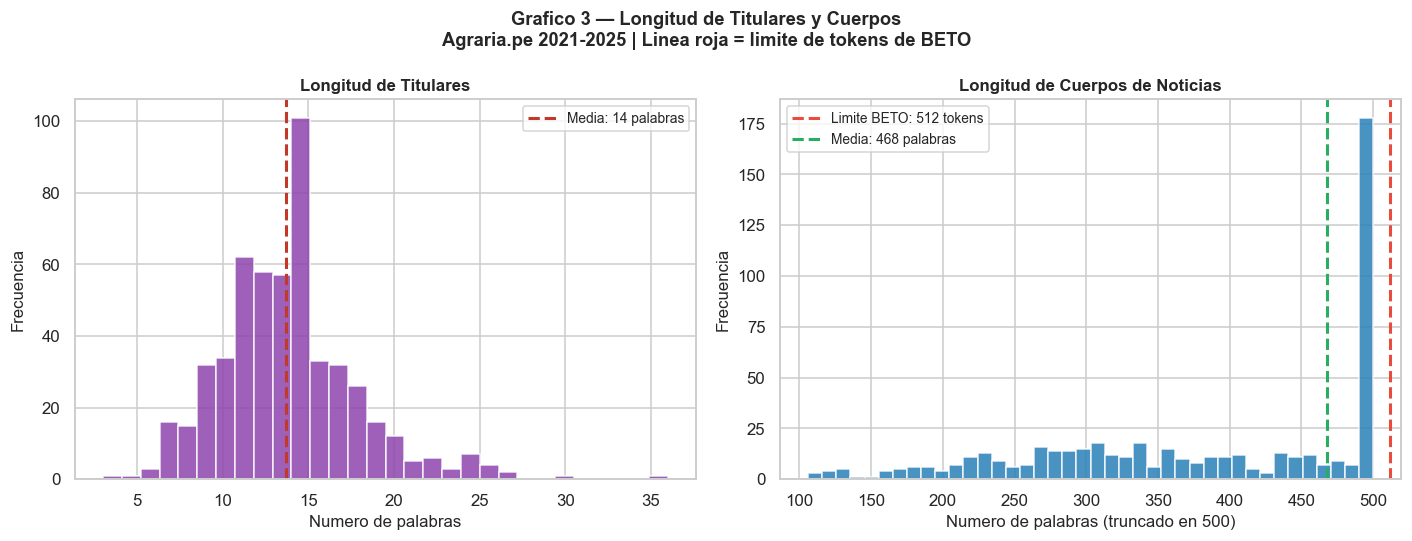

Guardado: pipeline/output/03_eda/act03_agraria_g3_longitud.png
Noticias que exceden 512 palabras (limite BETO): 29.7%


In [5]:
df_agr['len_titular'] = df_agr['titular'].fillna('').apply(lambda x: len(str(x).split()))
df_agr['len_cuerpo']  = df_agr['cuerpo_completo'].fillna('').apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Titular
axes[0].hist(df_agr['len_titular'], bins=30, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0].axvline(df_agr['len_titular'].mean(), color='#c0392b', linestyle='--', linewidth=2,
                label=f'Media: {df_agr["len_titular"].mean():.0f} palabras')
axes[0].set_xlabel('Numero de palabras', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Longitud de Titulares', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# Cuerpo
cuerpo_valido = df_agr[df_agr['len_cuerpo'] > 0]['len_cuerpo']
axes[1].hist(cuerpo_valido.clip(upper=500), bins=40, color='#2980b9', edgecolor='white', alpha=0.85)
axes[1].axvline(512, color='#e74c3c', linestyle='--', linewidth=2,
                label='Limite BETO: 512 tokens')
axes[1].axvline(cuerpo_valido.mean(), color='#27ae60', linestyle='--', linewidth=2,
                label=f'Media: {cuerpo_valido.mean():.0f} palabras')
axes[1].set_xlabel('Numero de palabras (truncado en 500)', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Longitud de Cuerpos de Noticias', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Grafico 3 — Longitud de Titulares y Cuerpos\n'
             'Agraria.pe 2021-2025 | Linea roja = limite de tokens de BETO',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_agraria_g3_longitud.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
pct_excede = (cuerpo_valido > 512).mean() * 100
print(f'Noticias que exceden 512 palabras (limite BETO): {pct_excede:.1f}%')


### Interpretacion

**Que muestra:** La distribucion de longitud de titulares y cuerpos de noticias. La linea roja marca el limite de 512 tokens del modelo BETO.

**Implicacion para el pipeline:** Los cuerpos que exceden 512 palabras deberan truncarse en la Fase 2 antes de pasarlos a BETO. Para la Fase 1, la longitud no afecta el conteo mensual de noticias.

**Implicacion para el modelo:** BETO (modelo de la Fase 2) tiene un limite de 512 tokens. Si la mayoria de los cuerpos exceden este limite, se evaluara si usar solo el titular o los primeros 512 tokens del cuerpo para el analisis de sentimiento.


## 3.4 Grafico 4 — Nube de palabras de titulares


In [6]:
try:
    from wordcloud import WordCloud
    import re

    # Limpiar y unir todos los titulares
    texto = ' '.join(df_agr['titular'].dropna().astype(str).tolist())
    texto = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑ\s]', ' ', texto)
    texto = texto.lower()

    # Stopwords en español
    stopwords_es = {'de','la','el','en','y','a','los','las','del','se','por',
                    'con','para','que','un','una','es','al','lo','su','sus',
                    'más','como','pero','si','no','le','ha','han','fue','ser'}

    wc = WordCloud(width=1000, height=500, background_color='white',
                   stopwords=stopwords_es, max_words=80,
                   colormap='RdYlGn', prefer_horizontal=0.8)
    wc.generate(texto)

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Grafico 4 — Nube de Palabras de Titulares\n'
                 'Agraria.pe 2021-2025 | Palabras mas frecuentes en noticias agricolas',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    g = OUTPUT['eda'] + 'act03_agraria_g4_wordcloud.png'
    plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g)
except ImportError:
    print('wordcloud no instalado. Instalando...')
    import subprocess
    subprocess.run(['pip', 'install', 'wordcloud', '--quiet'])
    print('Instalar wordcloud y re-ejecutar esta celda.')


wordcloud no instalado. Instalando...


Instalar wordcloud y re-ejecutar esta celda.


### Interpretacion

**Que muestra:** Las palabras mas frecuentes en los titulares de noticias de Agraria.pe. Las palabras grandes son las que aparecen con mayor frecuencia.

**Implicacion para el pipeline:** Si palabras como 'limon', 'precio', 'cosecha', 'lluvia' son prominentes, confirma que el scraping capturo noticias relevantes para el modelo. Si dominan palabras irrelevantes, puede ser necesario filtrar por keywords en la Actividad 5.

**Implicacion para el modelo:** Para la Fase 2 (BETO), las palabras dominantes orientan el tipo de sentimiento esperado. Noticias sobre 'precio alto' o 'escasez' tendran sentimiento negativo para el productor, mientras que 'buena cosecha' sera positivo.


In [7]:
print('[ACTIVIDAD 3 - AGRARIA.PE] COMPLETADA.')
print('Siguiente: pipeline/actividad_03_eda.ipynb (notebook principal)')


[ACTIVIDAD 3 - AGRARIA.PE] COMPLETADA.
Siguiente: pipeline/actividad_03_eda.ipynb (notebook principal)
